In [1]:
# Cell 0: setup + reload canonical
from google.colab import drive; drive.mount('/content/drive')
!pip install -q shap lightgbm

import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

pipe = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_train, X_test = split["X_train"], split["X_test"]
y_train, y_test = split["y_train"], split["y_test"]
print("Loaded canonical model + split:", X_test.shape)

Mounted at /content/drive
Loaded canonical model + split: (96171, 30)


In [4]:
# Cell 1 (fixed): inspect step names, then build explainer robustly
import shap

print("Pipeline steps:", list(pipe.named_steps.keys()))

# Grab preprocessor and model by position (prep is first, model is last) — name-agnostic
step_names = list(pipe.named_steps.keys())
prep  = pipe.named_steps[step_names[0]]
model = pipe.named_steps[step_names[-1]]
feat_names = prep.get_feature_names_out()
print("Using prep step:", step_names[0], "| model step:", step_names[-1])

# Sample + transform
X_sample = X_test.sample(n=3000, random_state=42)
X_sample_t = prep.transform(X_sample)
X_sample_df = pd.DataFrame(X_sample_t, columns=feat_names)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_df)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print("SHAP values shape:", np.array(shap_values).shape, "| features:", len(feat_names))

Pipeline steps: ['prep', 'm']
Using prep step: prep | model step: m
SHAP values shape: (3000, 74) | features: 74


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


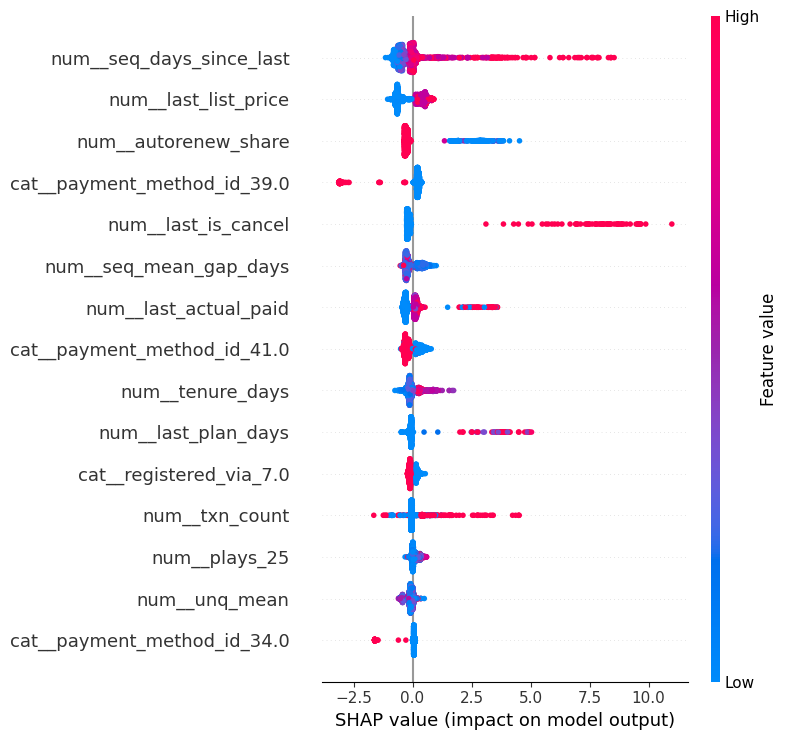

=== SHAP global importance (top 12) ===
                    feature  mean_abs_shap       pct
   num__seq_days_since_last       0.534429 10.477111
       num__last_list_price       0.510589 10.009759
       num__autorenew_share       0.482434  9.457796
cat__payment_method_id_39.0       0.408477  8.007915
        num__last_is_cancel       0.363044  7.117229
     num__seq_mean_gap_days       0.275175  5.394618
      num__last_actual_paid       0.267410  5.242386
cat__payment_method_id_41.0       0.263192  5.159702
           num__tenure_days       0.216907  4.252311
        num__last_plan_days       0.150462  2.949700
    cat__registered_via_7.0       0.143249  2.808300
             num__txn_count       0.134428  2.635366

Top 1: 10.5%  |  Top 3: 29.9%  |  Top 5: 45.1%
Features for 90% of SHAP magnitude: 22


In [5]:
# Cell 2: global SHAP beeswarm + importance ranking
import shap, matplotlib.pyplot as plt, numpy as np, pandas as pd, os
os.makedirs(f"{PROJECT}/reports/figures", exist_ok=True)

# Beeswarm (summary) plot
plt.figure()
shap.summary_plot(shap_values, X_sample_df, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# Honest global importance = mean(|SHAP|), with concentration check
mean_abs = np.abs(shap_values).mean(axis=0)
imp = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
imp["pct"] = 100 * imp["mean_abs_shap"] / imp["mean_abs_shap"].sum()
imp = imp.sort_values("pct", ascending=False).reset_index(drop=True)

print("=== SHAP global importance (top 12) ===")
print(imp.head(12).to_string(index=False))
print(f"\nTop 1: {imp.iloc[0]['pct']:.1f}%  |  Top 3: {imp.head(3)['pct'].sum():.1f}%"
      f"  |  Top 5: {imp.head(5)['pct'].sum():.1f}%")
print(f"Features for 90% of SHAP magnitude: {(imp['pct'].cumsum() <= 90).sum() + 1}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== HIGH-risk user — predicted churn prob: 1.000 ===


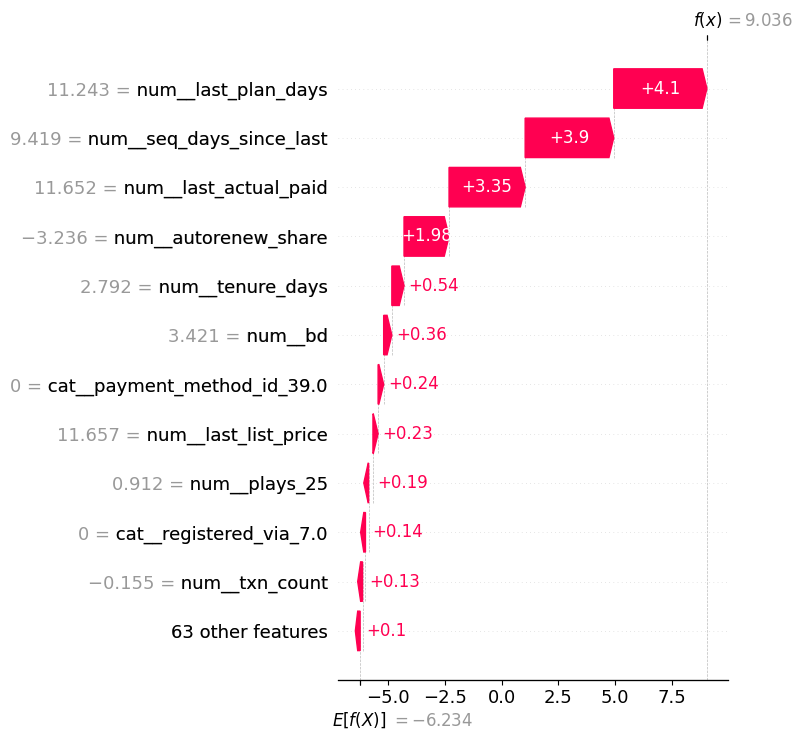


=== LOW-risk user — predicted churn prob: 0.000 ===


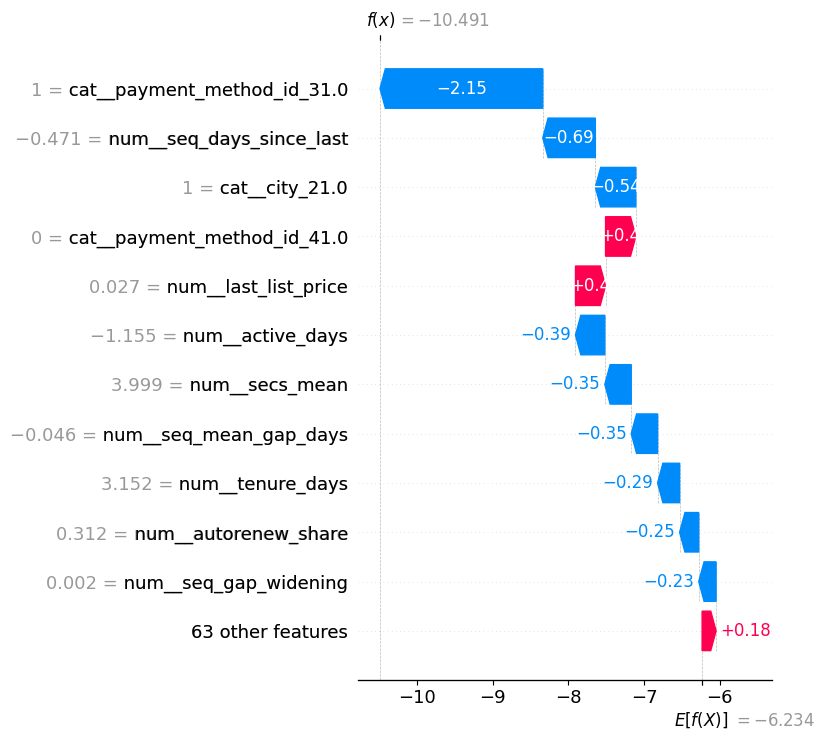

In [6]:
# Cell 3: per-customer waterfall (high-risk + low-risk examples)
probs = model.predict_proba(prep.transform(X_sample))[:, 1]
hi = int(np.argmax(probs))   # highest churn risk in sample
lo = int(np.argmin(probs))   # lowest

base = explainer.expected_value
base = base[1] if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0 else base

for label, idx in [("HIGH-risk", hi), ("LOW-risk", lo)]:
    print(f"\n=== {label} user — predicted churn prob: {probs[idx]:.3f} ===")
    expl = shap.Explanation(values=shap_values[idx], base_values=base,
                            data=X_sample_df.iloc[idx], feature_names=list(feat_names))
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.tight_layout()
    plt.savefig(f"{PROJECT}/reports/figures/shap_waterfall_{label.split('-')[0].lower()}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

## Summary — SHAP Interpretability

**Why SHAP, not just feature importance.** Gain-based importance tells you *which* features the model used overall, but not *how*, in *which direction*, or *why a specific user* was flagged. SHAP (Shapley values) decomposes each individual prediction into per-feature contributions with direction and magnitude — the foundation for both trustworthy global importance and per-customer explanations.

**Global finding — the model is well-distributed.** Built a `TreeExplainer` on a 3,000-user test sample. SHAP's honest importance (mean |SHAP|) showed no single feature exceeds ~11 %.This corrects the apparent over-concentration suggested by gain importance (top-2 ≈ 56%), which is a known artifact of gain's bias toward high-split-count features. The earlier worry that the model was "riding one or two features" is resolved: it is not.

**Top drivers (mean |SHAP|):** `seq_days_since_last` (10.5%), `last_list_price` (10.0%), `autorenew_share` (9.5%), `payment_method_id_39` (8.0%), `last_is_cancel` (7.1%). Notably, specific payment methods carry independent churn signal — a candidate for business investigation (e.g. whether certain payment channels are trial/promo paths with higher drop-off).

**Direction check (beeswarm + waterfalls).** The model learned domain-sensible relationships, confirmed globally and per-user: a long gap since last transaction pushes toward churn; high auto-renew share pushes away from it; recent cancellation increases risk. Two per-customer waterfall plots (one high-risk, one low-risk) showed coherent, opposite explanations.

**Artifacts saved** to `reports/figures/`: `shap_beeswarm.png`, `shap_waterfall_high.png`, `shap_waterfall_low.png`.

**Note for the business layer**: Waterfall plots are in log-odds space with standardized feature values. For non-technical retention users, these explanations will be re-presented with (a) original un-scaled values (e.g. "95 days since last transaction" not "11.2 std devs") and (b) plain-language reason strings instead of raw log-odds.

In [7]:
import sklearn, lightgbm, numpy, joblib, pandas
print("scikit-learn:", sklearn.__version__)
print("lightgbm:", lightgbm.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
lightgbm: 4.6.0
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.3


In [8]:
import json
meta = json.load(open(f"{PROJECT}/data/processed/meta_canonical.json"))
print("Feature count:", meta["n_features"])
for f in meta["features"]:
    print(f)

Feature count: 30
city
bd
age_missing
gender
registered_via
txn_count
cancel_count
autorenew_share
last_plan_days
last_actual_paid
last_list_price
last_discount
last_auto_renew
last_is_cancel
payment_method_id
secs_total
secs_mean
unq_mean
active_days
plays_100
plays_25
completion_ratio
has_logs
tenure_days
seq_days_since_last
seq_cancel_last3
seq_price_slope
seq_gap_widening
seq_mean_gap_days
seq_ar_dropped
